In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from transformers import SegformerForSemanticSegmentation
import torch
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [4]:
NUM_LABELS=2
CKPT_DIR = "/content/drive/MyDrive/spill_det/checkpoints"


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
best_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b1-finetuned-ade-512-512", num_labels=NUM_LABELS, ignore_mismatched_sizes=True
).to(device)

ckpt = torch.load(os.path.join(CKPT_DIR, "best.pt"), map_location=device)
best_model.load_state_dict(ckpt["model_state"])
best_model.eval()
print("loaded best model, val_mIoU was:", ckpt["best_miou"])

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b1-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


loaded best model, val_mIoU was: 0.7189269499564852


In [7]:
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

def build_mask(coco, ann_ids, h, w):
    mask = np.zeros((h, w), dtype=np.uint8)
    if not ann_ids:
        return mask
    for ann in coco.loadAnns(ann_ids):
        seg = ann.get("segmentation")
        if not seg:
            continue
        if isinstance(seg, list):
            rle = coco_mask.frPyObjects(seg, h, w)
            if isinstance(rle, list):
                rle = coco_mask.merge(rle)
        elif isinstance(seg["counts"], list):
            rle = coco_mask.frPyObjects(seg, h, w)
        else:
            rle = seg
        m = coco_mask.decode(rle)
        if m.ndim == 3:
            m = m.any(axis=2)
        mask = np.maximum(mask, m.astype(np.uint8))
    return mask

# load the test folder's annotation file once
TEST_DIR = "/content/drive/MyDrive/spill_det/dataset/test"
coco_test = COCO(os.path.join(TEST_DIR, "_annotations.coco.json"))

# build a lookup: filename -> (image_id, ann_ids, height, width)
filename_to_info = {}
for img_id, info in coco_test.imgs.items():
    ann_ids = coco_test.getAnnIds(imgIds=img_id)
    filename_to_info[info["file_name"]] = (ann_ids, info["height"], info["width"])

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


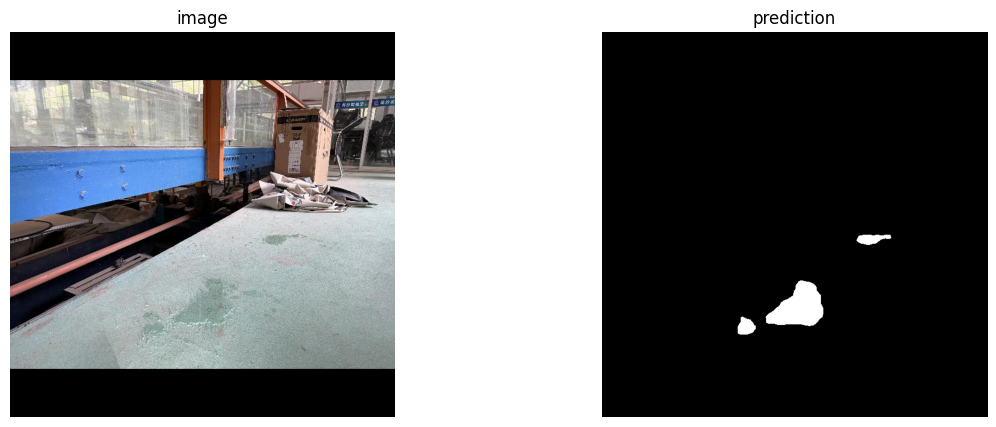

In [20]:


IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def predict_image(img_path):
    image = cv2.imread(img_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # normalize, same as training
    inp = image.astype(np.float32) / 255.0
    inp = (inp - IMAGENET_MEAN) / IMAGENET_STD
    inp = inp.transpose(2, 0, 1)
    pixel_values = torch.from_numpy(inp).unsqueeze(0).float().to(device)



    with torch.no_grad():
        outputs = best_model(pixel_values=pixel_values)
        logits = F.interpolate(outputs.logits, size=image.shape[:2], mode="bilinear", align_corners=False)
        pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()


            # ground truth mask lookup by filename
    # filename = os.path.basename(img_path)
    # ann_ids, h, w = filename_to_info[filename]
    # gt_mask = build_mask(coco_test, ann_ids, h, w)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(image); axes[0].set_title("image")
    # axes[1].imshow(gt_mask, cmap="gray"); axes[1].set_title("ground truth")
    axes[1].imshow(pred_mask, cmap="gray"); axes[1].set_title("prediction")
    for ax in axes: ax.axis("off")
    plt.show()

# just point this at any test image path
predict_image("/content/drive/MyDrive/spill_det/dataset/test/IMG_4531_JPG.rf.d5622bf9b8e366a19df164bccbb3e063.jpg")

In [9]:
!ls /content/drive/MyDrive/spill_det/dataset/test/

00e1adbd-IMG-20241227-WA0006_jpg.rf.30aa98bbb157aa9d66a10a553cce72fe.jpg
0107901_jpg.rf.53ef5cc3f768fffaa148b8abd4add275.jpg
0c1ef9a8-IMG-20241229-WA0038_jpg.rf.07a0137b8c0f8603c37c169fd11b7837.jpg
0c1ef9a8-IMG-20241229-WA0038_jpg.rf.204d419e3272cbcaf632c99717f3038d.jpg
0df555b9-IMG-20241227-WA0118_jpg.rf.b302dbabaea88e8c3ebf28de013c110e.jpg
0fcb48df-IMG-20241229-WA0082_jpg.rf.037a82470d4027f2f7fc086d5ddcd620.jpg
1_-444-_jpg.rf.f02a449b59fc9d25c8e0f6a9f56bea4a.jpg
1_-483-_jpg.rf.7900ef2a98e3ee139c95a1bf3f4f6730.jpg
14_jpeg_jpeg.rf.201b1b32d12e4877d1336d7b035362cc.jpg
1_-535-_jpg.rf.87c15c4a81060013d88726e4882d5a5e.jpg
1_-545-_jpg.rf.8bdbd9321abb624774c51bd9cdca5990.jpg
1_-655-_jpg.rf.5daf3fad5a1b6a0cca715637dab2962f.jpg
1_-663-_jpg.rf.da19a988652bd933fe17a3553e2a72a5.jpg
1_-698-_jpg.rf.b84386a26016ce80da5ff26e9ed90fd3.jpg
16_jpeg_jpeg.rf.dc74f3ca5431ba8a66ac82e4972e5594.jpg
1a1528d3-IMG-20241120-WA0006_jpg.rf.4a8ffaf7db3b65ff7c59e49202ba59a7.jpg
1a1528d3-IMG-20241120-WA0006_jpg.rf.61bf

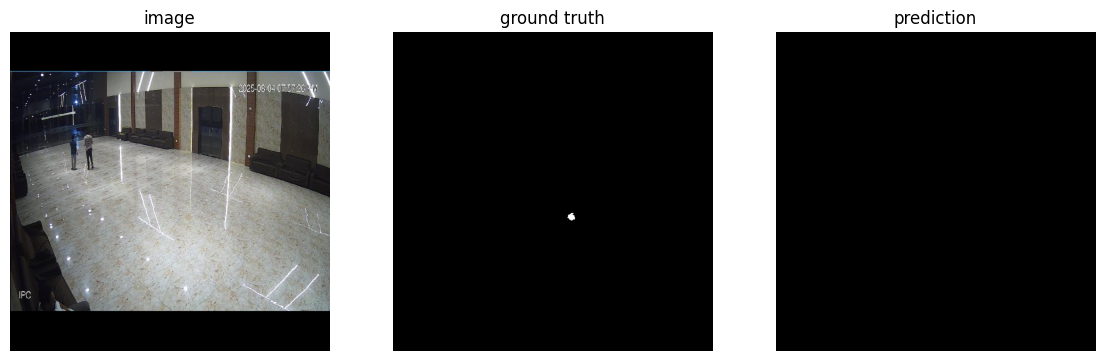

In [10]:
predict_image("/content/drive/MyDrive/spill_det/dataset/test/Screenshot-2025-08-06-195933_png.rf.49cc0e2dbcab01b1ca260d54fc89c4a6.jpg")

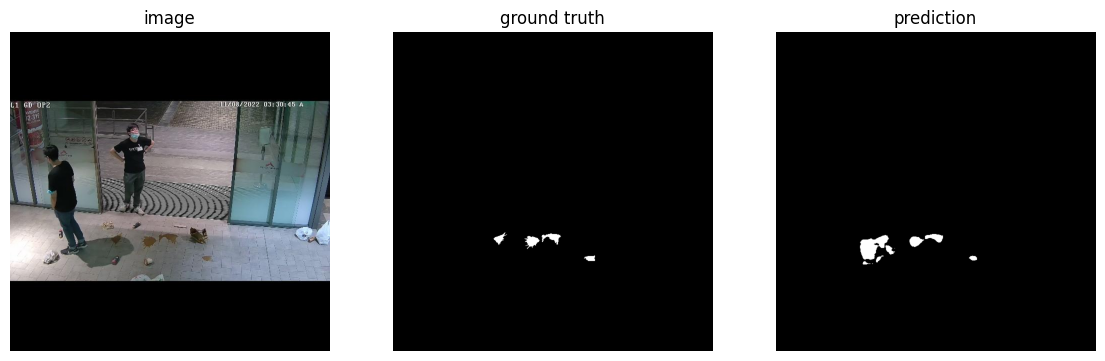

In [11]:
predict_image("/content/drive/MyDrive/spill_det/dataset/test/vlcsnap-2022-08-11-03h28m31s977_png.rf.bbb44910da0892f0586eb6d89cb66740.jpg")

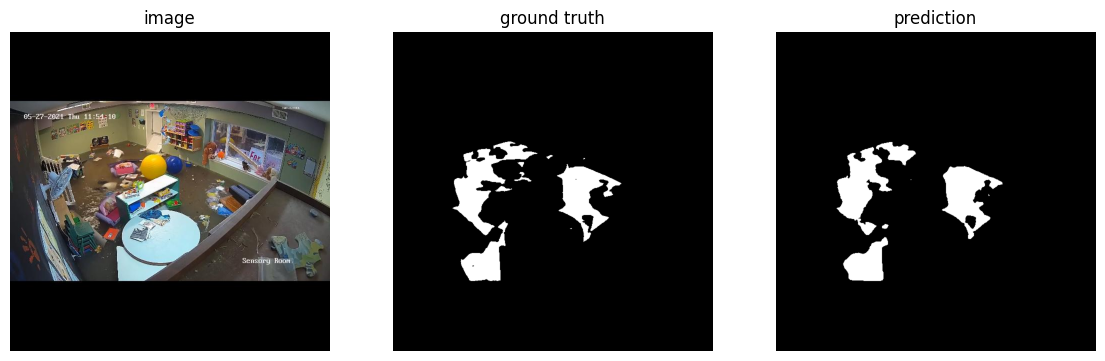

In [12]:
predict_image("/content/drive/MyDrive/spill_det/dataset/test/Video-shows-the-moment-a-Wentzville-day-care-flooded-during-storms-KSDK-News-1080p-_mp4-0719_jpg.rf.31048604f6e3dffcd4240570756b721b.jpg")

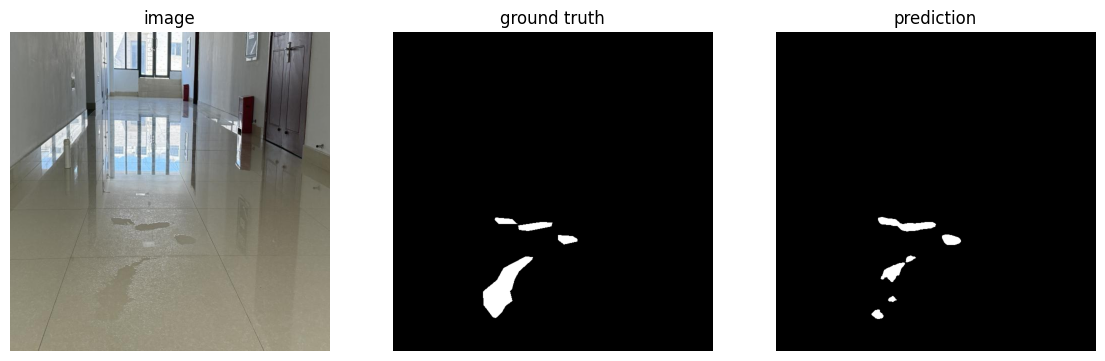

In [13]:
predict_image("/content/drive/MyDrive/spill_det/dataset/test/w8_jpg.rf.153c7376ef23ed2f32c34a3b926b78b1.jpg")

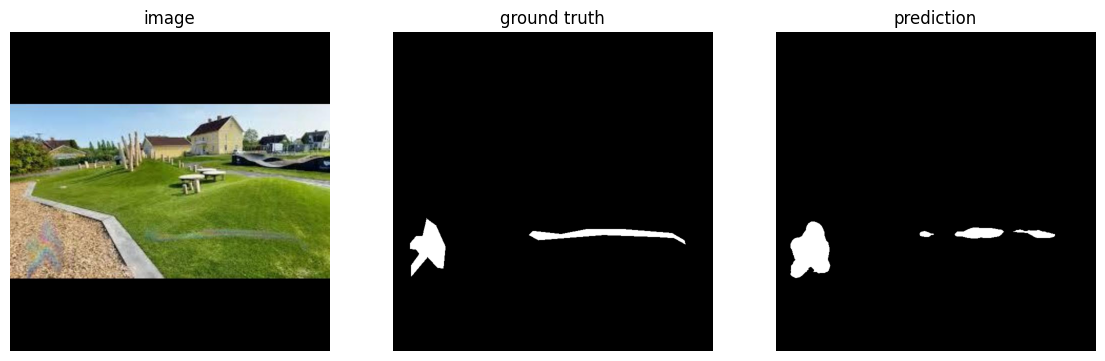

In [14]:
predict_image("/content/drive/MyDrive/spill_det/dataset/test/nmeddter_png.rf.ae9caf64f63f53fce4034e6f645ac887.jpg")

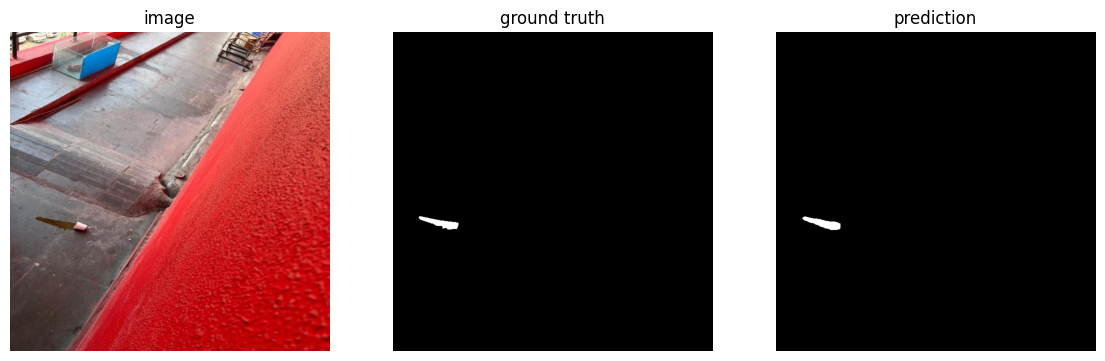

In [15]:
predict_image("/content/drive/MyDrive/spill_det/dataset/test/4e02a3b4-IMG-20241229-WA0186_jpg.rf.cd36cc17fe0ad9ded78b5f9bad5f75f1.jpg")

In [21]:
!ls "/content/drive/MyDrive/spill_det/dataset/Random_Images/"

'images (3).jpg'
'images (4).jpg'
'images (5).jpg'
'images (6).jpg'
'images (7).jpg'
 oil-water-leak-concrete-floor-need-clean-careful-dan-danger-accident-96402510.webp
 pexels-cottonbro-9376351.jpg
 pexels-leticiacurveloph-11993956.jpg


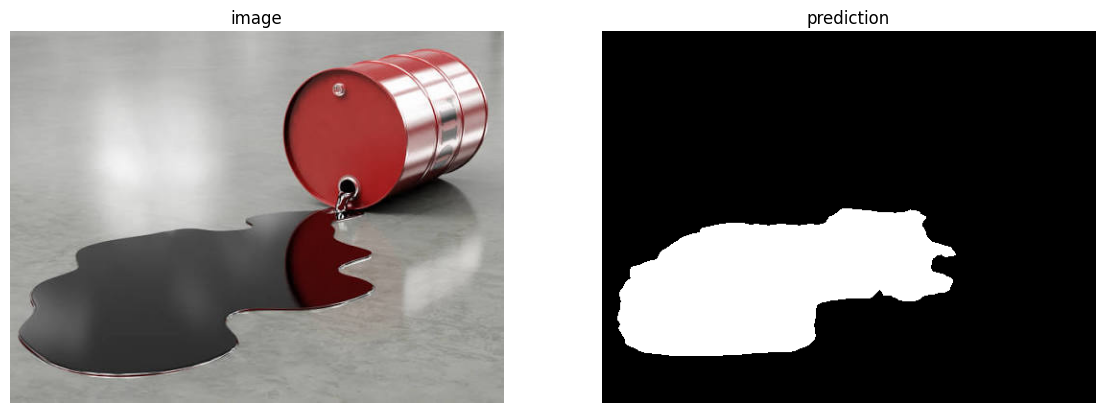

In [22]:
predict_image("/content/drive/MyDrive/spill_det/dataset/Random_Images/images (3).jpg")

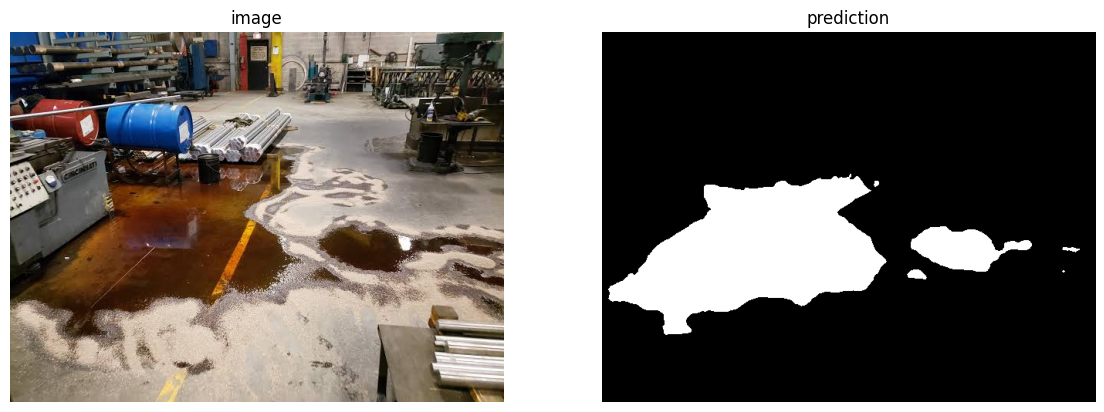

In [23]:
predict_image("/content/drive/MyDrive/spill_det/dataset/Random_Images/images (4).jpg")

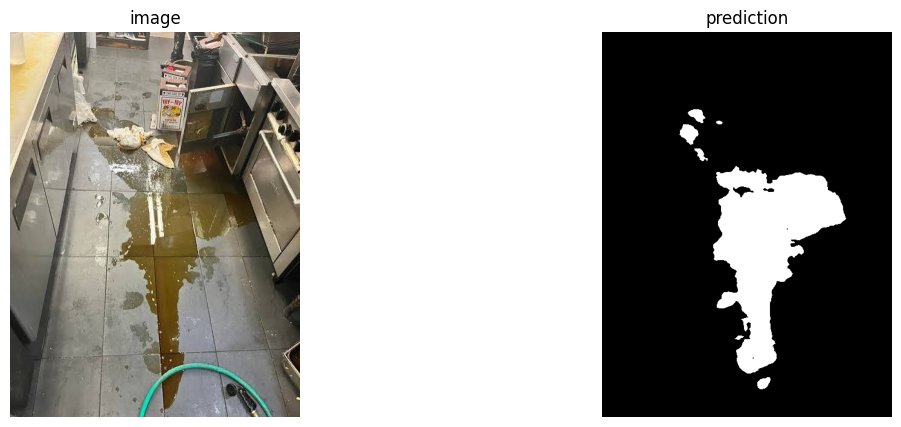

In [24]:
predict_image("/content/drive/MyDrive/spill_det/dataset/Random_Images/images (5).jpg")

In [ ]:
!ls "/content/drive/MyDrive/spill_det/dataset/Random_Images/"

In [25]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def predict_image(img_path):
    image = cv2.imread(img_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # normalize, same as training
    inp = image.astype(np.float32) / 255.0
    inp = (inp - IMAGENET_MEAN) / IMAGENET_STD
    inp = inp.transpose(2, 0, 1)
    pixel_values = torch.from_numpy(inp).unsqueeze(0).float().to(device)



    with torch.no_grad():
        outputs = best_model(pixel_values=pixel_values)
        logits = F.interpolate(outputs.logits, size=image.shape[:2], mode="bilinear", align_corners=False)
        pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()


        return image, pred_mask

In [27]:
image,  pred_mask = predict_image("/content/drive/MyDrive/spill_det/dataset/test/-_20251111211947_92_84_jpg.rf.ffee8785c609146bbad9c9cb4f5b7112.jpg")

In [28]:
def draw_segmentation_overlay(image, pred_mask, class_name="spill", color=(255, 0, 0), alpha=0.5):
    output = image.copy()
    colored_mask = np.zeros_like(image)
    colored_mask[pred_mask == 1] = color

    output = cv2.addWeighted(output, 1.0, colored_mask, alpha, 0)

    # label the mask - place text near its centroid
    ys, xs = np.where(pred_mask == 1)
    if len(xs) > 0:
        cx, cy = int(xs.mean()), int(ys.mean())
        cv2.putText(output, class_name, (cx, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    return output

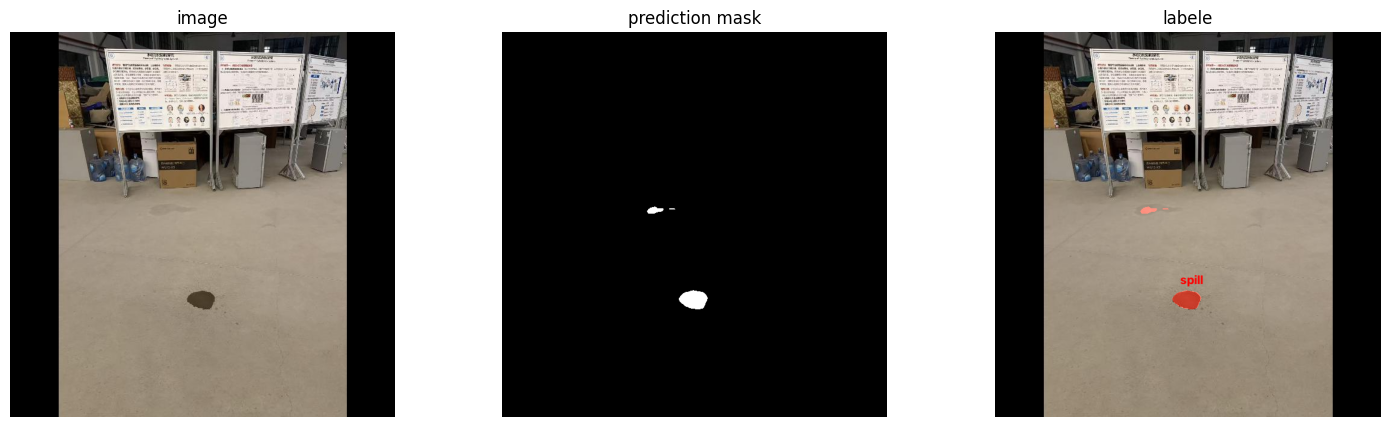

In [29]:
    labeled_img = draw_segmentation_overlay(image, pred_mask)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(image); axes[0].set_title("image")
    axes[1].imshow(pred_mask, cmap="gray"); axes[1].set_title("prediction mask")
    axes[2].imshow(labeled_img); axes[2].set_title("labele")
    for ax in axes: ax.axis("off")
    plt.show()

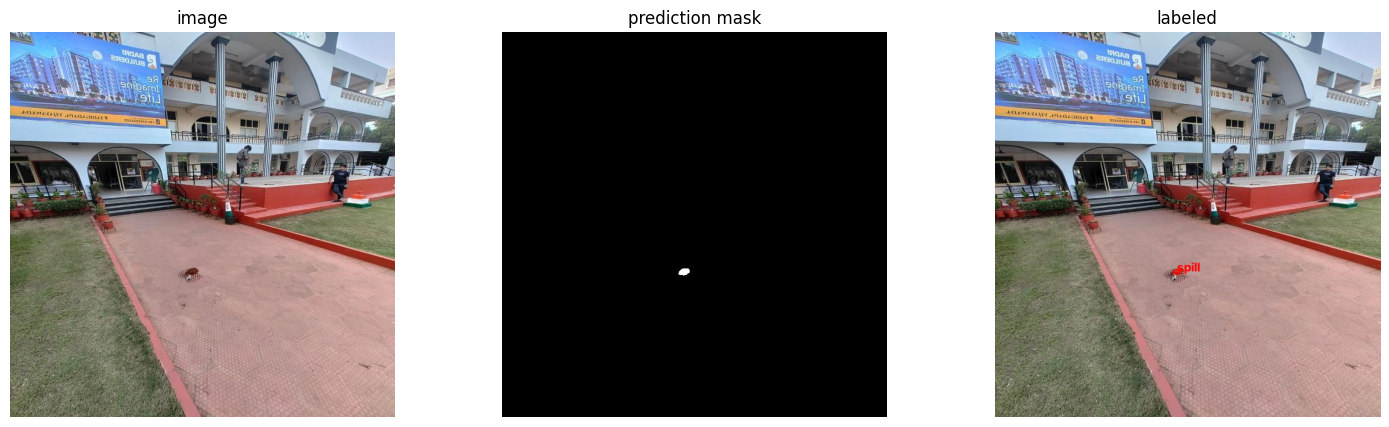

In [31]:
image,  pred_mask = predict_image("/content/drive/MyDrive/spill_det/dataset/test/0c1ef9a8-IMG-20241229-WA0038_jpg.rf.07a0137b8c0f8603c37c169fd11b7837.jpg")

labeled_img = draw_segmentation_overlay(image, pred_mask)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(image); axes[0].set_title("image")
axes[1].imshow(pred_mask, cmap="gray"); axes[1].set_title("prediction mask")
axes[2].imshow(labeled_img); axes[2].set_title("labeled")
for ax in axes: ax.axis("off")
plt.show()

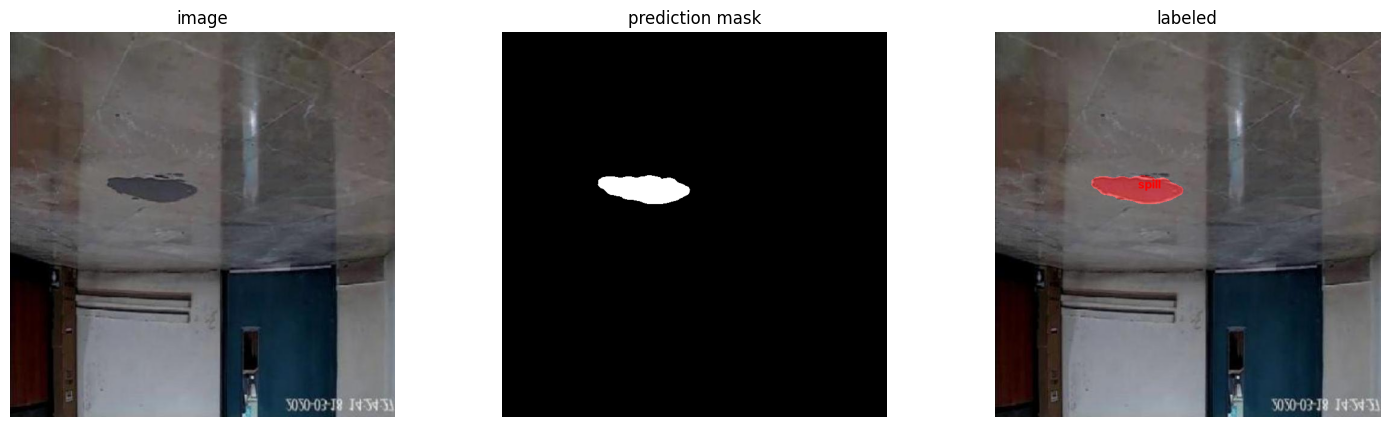

In [32]:
image,  pred_mask = predict_image("/content/drive/MyDrive/spill_det/dataset/test/1_-444-_jpg.rf.f02a449b59fc9d25c8e0f6a9f56bea4a.jpg")

labeled_img = draw_segmentation_overlay(image, pred_mask)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(image); axes[0].set_title("image")
axes[1].imshow(pred_mask, cmap="gray"); axes[1].set_title("prediction mask")
axes[2].imshow(labeled_img); axes[2].set_title("labeled")
for ax in axes: ax.axis("off")
plt.show()

In [ ]:
image,  pred_mask = predict_image("/content/drive/MyDrive/spill_det/dataset/test/0c1ef9a8-IMG-20241229-WA0038_jpg.rf.07a0137b8c0f8603c37c169fd11b7837.jpg")

labeled_img = draw_segmentation_overlay(image, pred_mask)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(image); axes[0].set_title("image")
axes[1].imshow(pred_mask, cmap="gray"); axes[1].set_title("prediction mask")
axes[2].imshow(labeled_img); axes[2].set_title("labeled")
for ax in axes: ax.axis("off")
plt.show()

In [38]:
!ls /content/drive/MyDrive/spill_det/dataset/valid

0103642_jpg.rf.35bba9a52f20e5ba8d8d0077a9f4f401.jpg
02fe8ef5-IMG-20241229-WA0213_jpg.rf.b6214b996d3e37663a1973e68e7e1183.jpg
02fe8ef5-IMG-20241229-WA0213_jpg.rf.c4c1f517e8839fd73423089b216a1d6c.jpg
0a885d85-IMG-20241229-WA0225_jpg.rf.27d0a344306c2628df7020cd59f816b2.jpg
0a885d85-IMG-20241229-WA0225_jpg.rf.54d7295462e3de852ef8b646de9dacf4.jpg
0beed64c-IMG-20241229-WA0161_jpg.rf.858e9755018883605ed557f69b79ea39.jpg
0cffe678-IMG-20241119-WA0013_jpg.rf.1a3198e7419b38aa9cf8bc413aefbc91.jpg
0cffe678-IMG-20241119-WA0013_jpg.rf.c14d85a8266c8795a252ea9dd867e092.jpg
0d00057c-IMG-20241227-WA0060_jpg.rf.7af5f76e714bab119efee186f592bb8e.jpg
0fd55c30-IMG-20241227-WA0101_jpg.rf.dabd9782d4387af5297feaf9d9eef782.jpg
1_-480-_jpg.rf.656fa49aef0a0956a7dec0cb53e57484.jpg
1_-495-_jpg.rf.54ec54439a2773d534bffe717d033f46.jpg
1_-524-_jpg.rf.84e1ced62b697506441e48d2aa82c932.jpg
1_-551-_jpg.rf.97f4dfef41d47dd491cba8998a7f48bd.jpg
1_-552-_jpg.rf.b225eb485c0423b7dedffff6d6e2d6da.jpg
1_-554-_jpg.rf.b68c17e9c128a2fa

In [39]:
import os
import numpy as np
import cv2
import torch
import torch.nn.functional as F
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

TEST_DIR = "/content/drive/MyDrive/spill_det/dataset/test"
coco_test = COCO(os.path.join(TEST_DIR, "_annotations.coco.json"))

def build_mask(coco, ann_ids, h, w):
    mask = np.zeros((h, w), dtype=np.uint8)
    if not ann_ids:
        return mask
    for ann in coco.loadAnns(ann_ids):
        seg = ann.get("segmentation")
        if not seg:
            continue
        if isinstance(seg, list):
            rle = coco_mask.frPyObjects(seg, h, w)
            if isinstance(rle, list):
                rle = coco_mask.merge(rle)
        elif isinstance(seg["counts"], list):
            rle = coco_mask.frPyObjects(seg, h, w)
        else:
            rle = seg
        m = coco_mask.decode(rle)
        if m.ndim == 3:
            m = m.any(axis=2)
        mask = np.maximum(mask, m.astype(np.uint8))
    return mask

# ---- run over every test image, accumulate global TP/FP/FN ----
total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0
per_image_ious = []

best_model.eval()
with torch.no_grad():
    for img_id, info in coco_test.imgs.items():
        img_path = os.path.join(TEST_DIR, info["file_name"])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ann_ids = coco_test.getAnnIds(imgIds=img_id)
        gt_mask = build_mask(coco_test, ann_ids, info["height"], info["width"])

        inp = image.astype(np.float32) / 255.0
        inp = (inp - IMAGENET_MEAN) / IMAGENET_STD
        inp = inp.transpose(2, 0, 1)
        pixel_values = torch.from_numpy(inp).unsqueeze(0).float().to(device)

        outputs = best_model(pixel_values=pixel_values)
        logits = F.interpolate(outputs.logits, size=gt_mask.shape, mode="bilinear", align_corners=False)
        pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

        pred_c = (pred_mask == 1)
        gt_c = (gt_mask == 1)

        tp = np.logical_and(pred_c, gt_c).sum()
        fp = np.logical_and(pred_c, ~gt_c).sum()
        fn = np.logical_and(~pred_c, gt_c).sum()
        tn = np.logical_and(~pred_c, ~gt_c).sum()

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

        union = tp + fp + fn
        if union > 0:
            per_image_ious.append(tp / union)

# ---- final metrics ----
precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else float("nan")
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else float("nan")
miou_global = total_tp / (total_tp + total_fp + total_fn)
miou_per_image = np.mean(per_image_ious)
f1 = 2 * precision * recall / (precision + recall)
pixel_accuracy = (total_tp + total_tn) / (total_tp + total_fp + total_fn + total_tn)

print(f"Test images evaluated: {len(coco_test.imgs)}")
print(f"Precision:        {precision:.4f}")
print(f"Recall:           {recall:.4f}")
print(f"F1 score:         {f1:.4f}")
print(f"mIoU (global):    {miou_global:.4f}")
print(f"mIoU (per-image): {miou_per_image:.4f}")
print(f"Pixel accuracy:   {pixel_accuracy:.4f}")

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Test images evaluated: 167
Precision:        0.8913
Recall:           0.8387
F1 score:         0.8642
mIoU (global):    0.7609
mIoU (per-image): 0.6291
Pixel accuracy:   0.9922
